# Base 3 — PM2.5 horário em Pequim

Holt-Winters univariado. Não usa variáveis externas. As datas de teste e o horizonte de um passo são os mesmos do Random Forest.

## 1. Holt-Winters

O alvo é `PM2.5`, µg/m³. O mínimo observado é positivo, então a busca inclui sazonalidade multiplicativa. A lacuna de cerca de 14 dias em 2014 fica fora do ajuste. Buracos de até dois dias usam forward-fill.

O ajuste usa só o passado. No teste, os hiperparâmetros ficam congelados e cada observação nova atualiza nível, tendência e sazonalidade.

In [1]:
from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

BASE_NUMBER = 3
TIME_COL = 'datetime'
TARGET_COL = 'PM2.5'
FREQUENCY = 'h'
TRAIN_RATIO = 0.8
ACF_LAGS = 168
LJUNG_LAGS = [1, 24, 48, 168]
METRICA = 'nivel'
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def achar_grupo(numero):
    aqui = Path.cwd().resolve()
    for candidato in [aqui, *aqui.parents]:
        pasta = candidato / "data" / f"base_{numero:02d}"
        if pasta.is_dir() and (
            (pasta / "train.csv").is_file()
            or (pasta / "raw.csv").is_file()
        ):
            return pasta
    raise FileNotFoundError("Pasta do grupo não encontrada.")

BASE_DIR = achar_grupo(BASE_NUMBER)

def carregar_observada(path, time_col, target_col):
    frame = pd.read_csv(path, usecols=[time_col, target_col])
    frame[time_col] = pd.to_datetime(frame[time_col], errors="raise")
    frame[target_col] = pd.to_numeric(frame[target_col], errors="coerce")
    frame = frame.dropna(subset=[time_col])
    return frame.groupby(time_col, sort=True)[target_col].mean()


def montar_serie_regular(limpa_path, train_path, test_path, time_col, target_col, freq, limite_ffill):
    """Grade regular com forward-fill.

    Uma lacuna maior que `limite_ffill` antes do teste encerra o histórico
    utilizável: o ajuste começa na primeira observação depois dela. Lacunas
    dentro da janela, inclusive no teste, são preenchidas só com o passado
    para manter o relógio sazonal e não entram no MAE.
    """
    if limpa_path is not None and Path(limpa_path).exists():
        base = carregar_observada(limpa_path, time_col, target_col).dropna()
    else:
        base = pd.Series(dtype=float)
    oficial = pd.concat(
        [
            carregar_observada(train_path, time_col, target_col),
            carregar_observada(test_path, time_col, target_col),
        ]
    )
    oficial = oficial.groupby(level=0).mean().sort_index().dropna()
    if len(base):
        oficial = oficial.combine_first(base).dropna().sort_index()
    teste = pd.read_csv(test_path, usecols=[time_col, target_col], parse_dates=[time_col])
    alvos_teste = pd.DatetimeIndex(pd.to_datetime(teste[time_col]).drop_duplicates()).sort_values()
    inicio_teste = alvos_teste.min()
    intervalos = oficial.index.to_series().diff()
    lacunas_antes = intervalos[(intervalos > limite_ffill) & (intervalos.index <= inicio_teste)]
    inicio = lacunas_antes.index.max() if len(lacunas_antes) else oficial.index.min()
    fim = max(oficial.index.max(), alvos_teste.max())
    grade = pd.date_range(inicio, fim, freq=freq)
    serie = oficial.reindex(grade)
    observado = serie.notna()
    buracos = int((~observado).sum())
    serie = serie.ffill()
    leading = int(serie.isna().sum())
    if leading:
        serie = serie.iloc[leading:]
        observado = observado.iloc[leading:]
    serie = serie.astype(float).copy()
    serie.index.freq = pd.tseries.frequencies.to_offset(freq)
    fora = alvos_teste.difference(serie.index)
    if len(fora):
        raise RuntimeError(f"{len(fora)} datas de teste não caíram na grade {freq}.")
    lacunas_no_teste = intervalos[(intervalos > limite_ffill) & (intervalos.index > inicio_teste)]
    meta = {
        "n_grade": int(len(serie)),
        "n_observados": int(observado.sum()),
        "n_imputados_ffill": buracos,
        "inicio_modelagem": str(serie.index.min()),
        "fim": str(serie.index.max()),
        "cortou_lacuna_anterior": bool(len(lacunas_antes)),
        "maior_lacuna_anterior_descartada": None if lacunas_antes.empty else str(lacunas_antes.max()),
        "lacunas_longas_no_teste": int(len(lacunas_no_teste)),
        "maior_lacuna_no_teste": None if lacunas_no_teste.empty else str(lacunas_no_teste.max()),
        "limite_ffill": str(limite_ffill),
        "n_alvos_teste": int(len(alvos_teste)),
    }
    return serie, observado.astype(bool), alvos_teste, meta


def preparar_ouro_semanal(path):
    bruto = pd.read_csv(path, usecols=["DATE", "GOLD_PRICE"])
    bruto["DATE"] = pd.to_datetime(bruto["DATE"], errors="raise")
    bruto = bruto.sort_values("DATE").drop_duplicates("DATE", keep="last")
    bruto = bruto.set_index("DATE")
    semanal = bruto.resample("W-FRI").agg(
        price_t=("GOLD_PRICE", "last"),
        cotacoes=("GOLD_PRICE", "count"),
    )
    semanal.index.name = "DATE"
    semanal["tem_cotacao"] = semanal["cotacoes"] > 0
    semanal["price_t"] = semanal["price_t"].ffill()
    semanal = semanal.dropna(subset=["price_t"])
    serie = semanal["price_t"].astype(float)
    serie.index.freq = semanal.index.freq
    n = len(serie)
    origens = np.arange(53, n - 1)
    if n != 2398 or len(origens) != 2344:
        raise RuntimeError(
            f"Série semanal inesperada: {n} semanas, {len(origens)} origens, "
            f"{serie.index.min()} a {serie.index.max()}."
        )
    corte = int(len(origens) * 0.75)
    origens_teste = origens[corte:]
    if len(origens_teste) != 586:
        raise RuntimeError(f"Teste semanal com {len(origens_teste)} origens, esperado 586.")
    fit_end = int(origens_teste[0])
    score_pos = origens_teste + 1
    meta = {
        "n_grade": int(n),
        "n_semanas_sem_cotacao": int((~semanal["tem_cotacao"]).sum()),
        "inicio": str(serie.index.min().date()),
        "fim": str(serie.index.max().date()),
        "primeira_origem_teste": str(serie.index[fit_end].date()),
        "ultimo_alvo_teste": str(serie.index[score_pos[-1]].date()),
        "n_alvos_teste": int(len(score_pos)),
    }
    return serie, semanal["tem_cotacao"].astype(bool), fit_end, score_pos, meta


def _parametros(resultado):
    params = resultado.params
    alpha = float(params["smoothing_level"])
    beta = params.get("smoothing_trend", np.nan)
    gamma = params.get("smoothing_seasonal", np.nan)
    phi = params.get("damping_trend", np.nan)
    beta = None if beta is None or not np.isfinite(beta) else float(beta)
    gamma = None if gamma is None or not np.isfinite(gamma) else float(gamma)
    phi = 1.0 if phi is None or not np.isfinite(phi) else float(phi)
    return alpha, beta, gamma, phi


def extrair_estado(resultado, spec):
    alpha, beta, gamma, phi = _parametros(resultado)
    if not spec["damped_trend"]:
        phi = 1.0
    nivel = float(np.asarray(resultado.level)[-1])
    tendencia = None
    if spec["trend"] is not None:
        tendencia = float(np.asarray(resultado.trend)[-1])
        if beta is None:
            beta = 0.0
    sazonal = None
    if spec["seasonal"] is not None:
        periodo = spec["seasonal_periods"]
        sazonal = np.asarray(resultado.season, dtype=float)[-periodo:].copy()
        if gamma is None:
            gamma = 0.0
    if not np.isfinite(nivel) or (sazonal is not None and not np.isfinite(sazonal).all()):
        raise RuntimeError("Estado final do Holt-Winters não é finito.")
    return {
        "level": nivel,
        "trend": tendencia,
        "season": sazonal,
        "alpha": alpha,
        "beta": beta,
        "gamma": gamma,
        "phi": phi,
        "trend_type": spec["trend"],
        "seasonal_type": spec["seasonal"],
    }


def prever_um_passo(estado):
    base = estado["level"] if estado["trend"] is None else estado["level"] + estado["phi"] * estado["trend"]
    if estado["seasonal_type"] is None:
        return float(base)
    fator = estado["season"][0]
    if estado["seasonal_type"] == "add":
        return float(base + fator)
    return float(base * fator)


def atualizar_estado(estado, observado):
    alpha = estado["alpha"]
    phi = estado["phi"]
    nivel = estado["level"]
    tendencia = estado["trend"]
    combinado = nivel if tendencia is None else nivel + phi * tendencia
    if estado["seasonal_type"] == "add":
        fator = estado["season"][0]
        novo_nivel = alpha * (observado - fator) + (1 - alpha) * combinado
    elif estado["seasonal_type"] == "mul":
        fator = estado["season"][0]
        novo_nivel = alpha * (observado / fator) + (1 - alpha) * combinado
    else:
        fator = None
        novo_nivel = alpha * observado + (1 - alpha) * combinado
    if tendencia is None:
        nova_tendencia = None
    else:
        beta = estado["beta"]
        nova_tendencia = beta * (novo_nivel - nivel) + (1 - beta) * phi * tendencia
    if estado["seasonal_type"] is None:
        nova_sazonal = None
    else:
        # Mesma atualização sazonal do statsmodels: usa o nível previsto
        # anterior, não o nível já corrigido pela observação nova.
        gamma = estado["gamma"]
        if estado["seasonal_type"] == "add":
            novo_fator = gamma * (observado - combinado) + (1 - gamma) * fator
        else:
            novo_fator = gamma * (observado / combinado) + (1 - gamma) * fator
        nova_sazonal = np.concatenate([estado["season"][1:], [novo_fator]])
    return {
        **estado,
        "level": float(novo_nivel),
        "trend": None if nova_tendencia is None else float(nova_tendencia),
        "season": nova_sazonal,
    }


def caminho_um_passo(estado, valores, inicio, fim_inclusivo, posicoes_avaliadas):
    previsoes = {}
    for posicao in range(inicio, fim_inclusivo + 1):
        previsao = prever_um_passo(estado)
        if posicao in posicoes_avaliadas:
            previsoes[posicao] = previsao
        estado = atualizar_estado(estado, float(valores[posicao]))
    return previsoes


def ajustar(serie, spec):
    modelo = ExponentialSmoothing(
        serie.astype(float),
        trend=spec["trend"],
        damped_trend=bool(spec["damped_trend"]) if spec["trend"] else False,
        seasonal=spec["seasonal"],
        seasonal_periods=spec["seasonal_periods"] if spec["seasonal"] else None,
        initialization_method="heuristic",
        freq=serie.index.freq,
    )
    return modelo.fit(optimized=True, remove_bias=False, use_brute=False)


def mae_seguro(real, previsto, retorno=False, nivel_anterior=None):
    real = np.asarray(real, dtype=float)
    previsto = np.asarray(previsto, dtype=float)
    if retorno:
        if np.any(previsto <= 0) or np.any(nivel_anterior <= 0) or np.any(real <= 0):
            return np.nan
        real = np.log(real / nivel_anterior)
        previsto = np.log(previsto / nivel_anterior)
    if not np.isfinite(previsto).all() or not np.isfinite(real).all():
        return np.nan
    return float(np.mean(np.abs(real - previsto)))


def buscar(serie, fit_end, candidatos, metrica, observado):
    treino = serie.iloc[: fit_end + 1]
    periodo_max = max((c["seasonal_periods"] or 0) for c in candidatos)
    val_len = max(2 * max(periodo_max, 1), int(round(0.2 * len(treino))))
    val_len = min(val_len, len(treino) // 2)
    linhas = []
    for spec in candidatos:
        periodo = spec["seasonal_periods"] or 0
        precisa = 2 * periodo if periodo else 10
        if len(treino) - val_len < precisa:
            linhas.append({**_spec_publica(spec), "status": "ignorado", "erro": "treino curto para o período", "val_mae": np.nan})
            continue
        print(f"Ajustando {spec['nome']}...", flush=True)
        inicio = time.perf_counter()
        try:
            ajuste = serie.iloc[: fit_end + 1 - val_len]
            resultado = ajustar(ajuste, spec)
            estado = extrair_estado(resultado, spec)
            posicoes = {i for i in range(len(ajuste), len(treino)) if bool(observado.iloc[i])}
            if len(posicoes) < 10:
                raise RuntimeError("validação sem observações reais suficientes")
            previsoes = caminho_um_passo(estado, treino.to_numpy(), len(ajuste), len(treino) - 1, posicoes)
            ordem = sorted(posicoes)
            previsto = [previsoes[i] for i in ordem]
            real = treino.iloc[ordem].to_numpy()
            anterior = treino.iloc[np.array(ordem) - 1].to_numpy()
            erro = mae_seguro(real, previsto, retorno=metrica == "retorno", nivel_anterior=anterior)
            alpha, beta, gamma, phi = _parametros(resultado)
            if not spec["damped_trend"]:
                phi = 1.0
            linhas.append(
                {
                    **_spec_publica(spec),
                    "status": "ok" if np.isfinite(erro) else "invalido",
                    "erro": "" if np.isfinite(erro) else "previsão não finita",
                    "val_mae": erro,
                    "alpha": alpha,
                    "beta": beta,
                    "gamma": gamma,
                    "phi": phi,
                    "aic": float(resultado.aic) if np.isfinite(resultado.aic) else np.nan,
                    "fit_seconds": time.perf_counter() - inicio,
                }
            )
        except Exception as exc:
            linhas.append(
                {
                    **_spec_publica(spec),
                    "status": "falhou",
                    "erro": str(exc).split("\n")[0][:300],
                    "val_mae": np.nan,
                    "fit_seconds": time.perf_counter() - inicio,
                }
            )
    tabela = pd.DataFrame(linhas).sort_values(["val_mae", "nome"], na_position="last").reset_index(drop=True)
    validos = tabela[tabela.status.eq("ok") & tabela.val_mae.notna()]
    if validos.empty:
        raise RuntimeError("Nenhum candidato de Holt-Winters ajustou na validação.")
    melhor_nome = validos.iloc[0]["nome"]
    escolhido = next(spec for spec in candidatos if spec["nome"] == melhor_nome)
    return tabela, escolhido, val_len


def _spec_publica(spec):
    return {
        "nome": spec["nome"],
        "trend": spec["trend"] or "nenhuma",
        "seasonal": spec["seasonal"] or "nenhuma",
        "seasonal_periods": spec["seasonal_periods"],
        "damped_trend": bool(spec["damped_trend"]) if spec["trend"] else False,
    }


def avaliar(serie, fit_end, score_pos, spec, metrica, tem_cotacao=None):
    inicio_ajuste = time.perf_counter()
    resultado = ajustar(serie.iloc[: fit_end + 1], spec)
    estado = extrair_estado(resultado, spec)
    segundos_ajuste = time.perf_counter() - inicio_ajuste
    inicio_wf = time.perf_counter()
    posicoes = set(int(p) for p in score_pos)
    previsoes = caminho_um_passo(
        estado,
        serie.to_numpy(),
        fit_end + 1,
        int(max(score_pos)),
        posicoes,
    )
    segundos_wf = time.perf_counter() - inicio_wf
    ordem = [int(p) for p in score_pos]
    previsto = np.array([previsoes[p] for p in ordem], dtype=float)
    real = serie.iloc[ordem].to_numpy()
    anterior = serie.iloc[np.array(ordem) - 1].to_numpy()
    frame = pd.DataFrame(
        {
            "origin_time": serie.index[np.array(ordem) - 1],
            "target_time": serie.index[ordem],
            "y_true": real,
            "y_pred": previsto,
        }
    )
    frame["residuo"] = frame.y_true - frame.y_pred
    if metrica == "retorno":
        frame["y_true_return"] = np.log(frame.y_true / anterior)
        frame["y_pred_return"] = np.log(frame.y_pred / anterior)
        frame["residuo_return"] = frame.y_true_return - frame.y_pred_return
        frame["target_has_new_quote"] = tem_cotacao.iloc[ordem].to_numpy()
    alpha, beta, gamma, phi = _parametros(resultado)
    if not spec["damped_trend"]:
        phi = 1.0
    info = {
        "alpha": alpha,
        "beta": beta,
        "gamma": gamma,
        "phi": phi,
        "aic_treino": float(resultado.aic) if np.isfinite(resultado.aic) else None,
        "segundos_ajuste_final": segundos_ajuste,
        "segundos_walk_forward": segundos_wf,
        "nivel_final_treino": estado["level"],
        "tendencia_final_treino": estado["trend"],
    }
    return frame, resultado, info


LIMITE_FFILL = pd.Timedelta('2D')
serie, observado, alvos_teste, meta_serie = montar_serie_regular(
    BASE_DIR / 'prepared.csv',
    BASE_DIR / "train.csv",
    BASE_DIR / "test.csv",
    TIME_COL, TARGET_COL, FREQUENCY, LIMITE_FFILL,
)
fit_end = int(serie.index.searchsorted(alvos_teste.min()) - 1)
score_pos = serie.index.get_indexer(alvos_teste)
assert (score_pos >= 0).all()
tem_cotacao = None
print(pd.Series(meta_serie, name="valor").to_string())
print(f"Último ponto do ajuste: {serie.index[fit_end]}")
print(f"Primeiro alvo de teste: {serie.index[score_pos[0]]} | n={len(score_pos)}")


n_grade                                           18967
n_observados                                      18558
n_imputados_ffill                                   409
inicio_modelagem                    2014-12-31 17:00:00
fim                                 2017-02-28 23:00:00
cortou_lacuna_anterior                             True
maior_lacuna_anterior_descartada       14 days 08:00:00
lacunas_longas_no_teste                               0
maior_lacuna_no_teste                              None
limite_ffill                            2 days 00:00:00
n_alvos_teste                                      6828
Último ponto do ajuste: 2016-05-16 01:00:00
Primeiro alvo de teste: 2016-05-16 02:00:00 | n=6828


## 2. Otimização Holt-Winters

A busca ocorre na cauda do treino, cerca de 20% e com pelo menos dois ciclos sazonais. O teste não entra na escolha. `alpha`, `beta`, `gamma` e `phi` são estimados no ajuste, com inicialização heurística.

In [2]:
CANDIDATOS = [
    {
        'nome': 'suavização simples',
        'trend': None,
        'seasonal': None,
        'seasonal_periods': None,
        'damped_trend': False,
    },
    {
        'nome': 'Holt aditivo',
        'trend': 'add',
        'seasonal': None,
        'seasonal_periods': None,
        'damped_trend': False,
    },
    {
        'nome': 'Holt aditivo amortecido',
        'trend': 'add',
        'seasonal': None,
        'seasonal_periods': None,
        'damped_trend': True,
    },
    {
        'nome': 'sazonalidade aditiva diária',
        'trend': None,
        'seasonal': 'add',
        'seasonal_periods': 24,
        'damped_trend': False,
    },
    {
        'nome': 'Holt-Winters aditivo diário',
        'trend': 'add',
        'seasonal': 'add',
        'seasonal_periods': 24,
        'damped_trend': False,
    },
    {
        'nome': 'Holt-Winters aditivo amortecido diário',
        'trend': 'add',
        'seasonal': 'add',
        'seasonal_periods': 24,
        'damped_trend': True,
    },
    {
        'nome': 'Holt-Winters multiplicativo diário',
        'trend': 'add',
        'seasonal': 'mul',
        'seasonal_periods': 24,
        'damped_trend': False,
    },
    {
        'nome': 'Holt-Winters aditivo semanal',
        'trend': 'add',
        'seasonal': 'add',
        'seasonal_periods': 168,
        'damped_trend': False,
    },
    {
        'nome': 'Holt-Winters aditivo amortecido semanal',
        'trend': 'add',
        'seasonal': 'add',
        'seasonal_periods': 168,
        'damped_trend': True,
    },
    {
        'nome': 'Holt-Winters multiplicativo semanal',
        'trend': 'add',
        'seasonal': 'mul',
        'seasonal_periods': 168,
        'damped_trend': False,
    },
]

busca, escolhido, val_len = buscar(serie, fit_end, CANDIDATOS, METRICA, observado)
print(f"Observações na cauda de validação: {val_len}")
display(busca)
print("Escolhido:", escolhido["nome"])

resultado, info = None, None
previsoes, resultado, info = avaliar(
    serie, fit_end, score_pos, escolhido, METRICA, tem_cotacao=tem_cotacao,
)
origem = serie.loc[previsoes.origin_time].to_numpy()
predictions = previsoes.rename(columns={"y_pred": "y_pred_hw", "residuo": "residuo_hw"})
predictions["y_pred_persistencia"] = origem
predictions["erro_absoluto_hw"] = predictions.residuo_hw.abs()
predictions["erro_quadratico_hw"] = predictions.residuo_hw.pow(2)
if METRICA == "retorno":
    predictions["y_pred_return_hw"] = predictions.y_pred_return
    predictions["residuo_hw_return"] = predictions.residuo_return
    predictions["erro_absoluto_return"] = predictions.residuo_return.abs()
    predictions["erro_quadratico_return"] = predictions.residuo_return.pow(2)
print(pd.Series(info, name="valor").to_string())
display(predictions.head())


Ajustando suavização simples...


Ajustando Holt aditivo...


Ajustando Holt aditivo amortecido...


Ajustando sazonalidade aditiva diária...


Ajustando Holt-Winters aditivo diário...


...

Ajustando Holt-Winters multiplicativo semanal...


Observações na cauda de validação: 2407


,nome,trend,seasonal,seasonal_periods,damped_trend,status,erro,val_mae,alpha,beta,gamma,phi,aic,fit_seconds
0,suavização simples,nenhuma,nenhuma,NaN,False,ok,,13.950253,0.500000,NaN,NaN,1.00,62711.384724,0.021657
1,Holt aditivo amortecido,add,nenhuma,NaN,True,ok,,14.268131,0.500000,0.050000,NaN,0.99,63058.473297,0.047332
2,Holt aditivo,add,nenhuma,NaN,False,ok,,14.419951,0.500000,0.050000,NaN,1.00,63167.684120,0.052721
3,sazonalidade aditiva diária,nenhuma,add,24.0,False,ok,,50.725838,0.020833,NaN,0.048958,1.00,81363.591631,0.028749
4,Holt-Winters aditivo amortecido diário,add,add,24.0,True,ok,,50.850590,0.020833,0.002083,0.048958,0.99,81524.780675,0.074675
5,Holt-Winters aditivo diário,add,add,24.0,False,ok,,51.355766,0.020833,0.002083,0.048958,1.00,82782.331681,0.074639
6,Holt-Winters multiplicativo diário,add,mul,24.0,False,ok,,52.339418,0.020833,0.002083,0.048958,1.00,82570.577366,0.073486
7,Holt-Winters aditivo amortecido semanal,add,add,168.0,True,ok,,60.236671,0.002976,0.000298,0.049851,0.99,85290.615278,0.079606
8,Holt-Winters multiplicativo semanal,add,mul,168.0,False,ok,,60.812711,0.002976,0.000298,0.049851,1.00,88696.785709,0.099136
9,Holt-Winters aditivo semanal,add,add,168.0,False,ok,,61.853310,0.002976,0.000298,0.049851,1.00,88246.559345,0.075879


Escolhido: suavização simples
alpha                         0.500000
beta                               NaN
gamma                              NaN
phi                           1.000000
aic_treino                79107.956340
segundos_ajuste_final         0.009328
segundos_walk_forward         0.006480
nivel_final_treino           38.142884
tendencia_final_treino             NaN


,origin_time,target_time,y_true,y_pred_hw,residuo_hw,y_pred_persistencia,erro_absoluto_hw,erro_quadratico_hw
0,2016-05-16 01:00:00,2016-05-16 02:00:00,22.0,38.142884,-16.142884,27.0,16.142884,260.592711
1,2016-05-16 02:00:00,2016-05-16 03:00:00,22.0,30.071442,-8.071442,22.0,8.071442,65.148178
2,2016-05-16 03:00:00,2016-05-16 04:00:00,37.0,26.035721,10.964279,22.0,10.964279,120.215413
3,2016-05-16 04:00:00,2016-05-16 05:00:00,33.0,31.517861,1.482139,37.0,1.482139,2.196737
4,2016-05-16 05:00:00,2016-05-16 06:00:00,36.0,32.258930,3.741070,33.0,3.741070,13.995603


## 3. MAE e demais métricas Holt-Winters

O MAE principal é calculado fora da amostra. A persistência (`ŷ(t+1)=y(t)`) mostra se o Holt-Winters agrega valor.

In [3]:
def metric_row(name, real, values):
    real = np.asarray(real, dtype=float)
    values = np.asarray(values, dtype=float)
    residuo = real - values
    ss_tot = np.sum((real - real.mean()) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - np.sum(residuo ** 2) / ss_tot
    return {
        "modelo": name,
        "MAE": float(np.mean(np.abs(residuo))),
        "RMSE": float(np.sqrt(np.mean(residuo ** 2))),
        "MedAE": float(np.median(np.abs(residuo))),
        "R2": float(r2),
        "vies_medio": float(np.mean(residuo)),
    }

if METRICA == "retorno":
    metrics = pd.DataFrame([
        metric_row("Holt-Winters", predictions.y_true_return, predictions.y_pred_return_hw),
        metric_row("Persistência", predictions.y_true_return, np.zeros(len(predictions))),
        metric_row("Holt-Winters — preço", predictions.y_true, predictions.y_pred_hw),
        metric_row("Persistência — preço", predictions.y_true, predictions.y_pred_persistencia),
    ])
else:
    metrics = pd.DataFrame([
        metric_row("Holt-Winters", predictions.y_true, predictions.y_pred_hw),
        metric_row("Persistência", predictions.y_true, predictions.y_pred_persistencia),
    ])
display(metrics)


,modelo,MAE,RMSE,MedAE,R2,vies_medio
0,Holt-Winters,14.196441,25.169697,7.570642,0.910919,-0.027547
1,Persistência,10.396895,19.289678,6.000000,0.947679,-0.001172


## 4. Resíduos individuais Holt-Winters

O resíduo é o valor real menos a previsão, em cada data de teste.

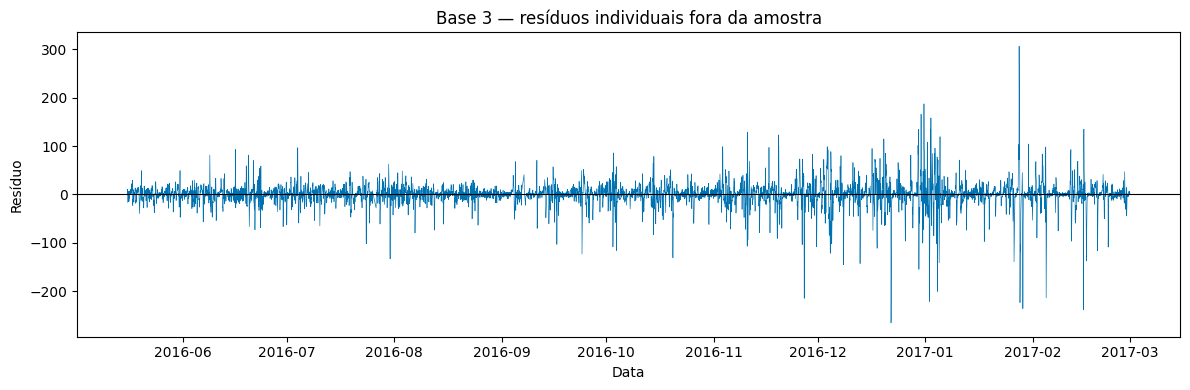

,origin_time,target_time,y_true,y_pred_hw,y_pred_persistencia,residuo_hw,erro_absoluto_hw,erro_quadratico_hw
0,2016-05-16 01:00:00,2016-05-16 02:00:00,22.0,38.142884,27.0,-16.142884,16.142884,260.592711
1,2016-05-16 02:00:00,2016-05-16 03:00:00,22.0,30.071442,22.0,-8.071442,8.071442,65.148178
2,2016-05-16 03:00:00,2016-05-16 04:00:00,37.0,26.035721,22.0,10.964279,10.964279,120.215413
3,2016-05-16 04:00:00,2016-05-16 05:00:00,33.0,31.517861,37.0,1.482139,1.482139,2.196737
4,2016-05-16 05:00:00,2016-05-16 06:00:00,36.0,32.258930,33.0,3.741070,3.741070,13.995603
5,2016-05-16 06:00:00,2016-05-16 07:00:00,37.0,34.129465,36.0,2.870535,2.870535,8.239970
6,2016-05-16 07:00:00,2016-05-16 08:00:00,42.0,35.564733,37.0,6.435267,6.435267,41.412667
7,2016-05-16 08:00:00,2016-05-16 09:00:00,24.0,38.782366,42.0,-14.782366,14.782366,218.518353
8,2016-05-16 09:00:00,2016-05-16 10:00:00,34.0,31.391183,24.0,2.608817,2.608817,6.805925
9,2016-05-16 10:00:00,2016-05-16 11:00:00,32.0,32.695592,34.0,-0.695592,0.695592,0.483848


In [4]:
residuals = predictions.residuo_return if METRICA == "retorno" else predictions.residuo_hw
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(predictions.target_time, residuals, lw=.45, color="#0072b2")
ax.axhline(0, color="black", lw=.8)
ax.set(title=f"Base {BASE_NUMBER} — resíduos individuais fora da amostra", xlabel="Data", ylabel="Resíduo")
fig.tight_layout()
plt.show()
colunas = [
    "origin_time", "target_time", "y_true", "y_pred_hw", "y_pred_persistencia",
    "residuo_hw", "erro_absoluto_hw", "erro_quadratico_hw",
]
if METRICA == "retorno":
    colunas += ["y_true_return", "y_pred_return_hw", "residuo_return", "erro_absoluto_return", "erro_quadratico_return"]
display(predictions[colunas].head(20))


## 5. ACF Holt-Winters

A ACF inspeciona dependência residual.

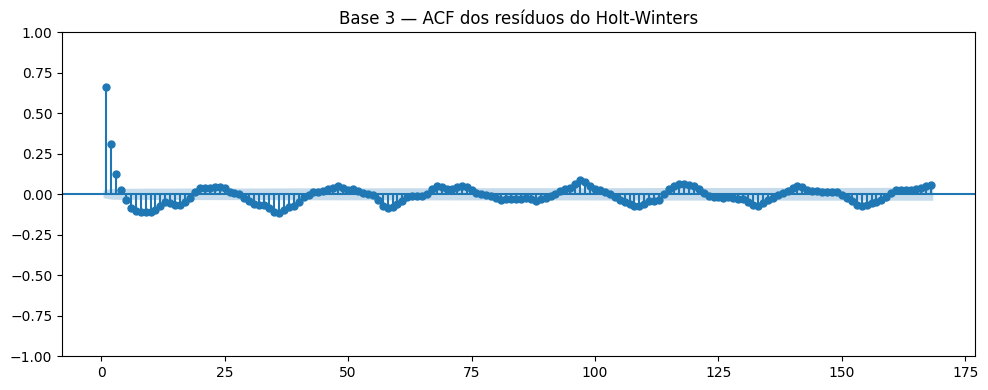

In [5]:
usable_acf_lags = min(ACF_LAGS, max(1, len(residuals) // 2 - 1))
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(residuals, lags=usable_acf_lags, zero=False, ax=ax)
ax.set_title(f"Base {BASE_NUMBER} — ACF dos resíduos do Holt-Winters")
fig.tight_layout()
plt.show()


## 6. Ljung-Box Holt-Winters

O Ljung-Box testa conjuntamente a hipótese de ausência de autocorrelação até cada lag informado.

In [6]:
usable_ljung_lags = sorted({lag for lag in LJUNG_LAGS if 0 < lag < len(residuals)})
ljung_box = acorr_ljungbox(residuals, lags=usable_ljung_lags, return_df=True)
ljung_box["rejeita_ruido_branco_5pct"] = ljung_box.lb_pvalue < .05
display(ljung_box)


,lb_stat,lb_pvalue,rejeita_ruido_branco_5pct
1,2994.980108,0.0,True
24,4428.190760,0.0,True
48,4967.440738,0.0,True
168,6261.154704,0.0,True


In [7]:
import hashlib
import json
import platform
import statsmodels

ROOT = BASE_DIR.parent.parent
if BASE_NUMBER == 5:
    input_paths = [BASE_DIR / 'raw.csv']
else:
    input_paths = [
        path for path in (
            BASE_DIR / 'prepared.csv',
            BASE_DIR / 'train.csv',
            BASE_DIR / 'test.csv',
        )
        if path.is_file()
    ]
input_hashes = {
    str(path.relative_to(ROOT)): hashlib.sha256(path.read_bytes()).hexdigest()
    for path in input_paths
}
base_names = {
    1: 'Base 1 — Bitcoin (BTC)',
    2: 'Base 2 — tráfego horário da I-94',
    3: 'Base 3 — PM2.5 horário em Pequim',
    4: 'Base 4 — temperatura em Jena',
    5: 'Base 5 — ouro semanal',
}
search_fit_seconds = float(busca['fit_seconds'].fillna(0).sum())
evaluation_seconds = float(info['segundos_ajuste_final'] + info['segundos_walk_forward'])
selected_parameters = _spec_publica(escolhido)
selected_parameters.update({
    key: info[key] for key in ('alpha', 'beta', 'gamma', 'phi')
})
fit_log = pd.DataFrame([
    {
        'etapa': 'ajuste inicial',
        'linhas_treino': fit_end + 1,
        'duracao_s': info['segundos_ajuste_final'],
    },
    {
        'etapa': 'walk-forward com atualização do estado',
        'pontos_teste': len(predictions),
        'duracao_s': info['segundos_walk_forward'],
    },
])
experiment_record = pd.DataFrame([{
    'base': base_names[BASE_NUMBER],
    'arquivos': json.dumps(list(input_hashes), ensure_ascii=False),
    'sha256_arquivos': json.dumps(input_hashes, ensure_ascii=False),
    'frequencia': FREQUENCY,
    'alvo_original': TARGET_COL,
    'alvo_modelo': 'retorno log de um passo' if METRICA == 'retorno' else 'nível de um passo',
    'horizonte_provisorio': f'1 passo ({FREQUENCY})',
    'split_treino': TRAIN_RATIO,
    'random_state': RANDOM_STATE,
    'linhas_treino': fit_end + 1,
    'linhas_teste': len(predictions),
    'origem_teste_inicial': predictions.origin_time.min(),
    'origem_teste_final': predictions.origin_time.max(),
    'numero_features': 0,
    'features': json.dumps([], ensure_ascii=False),
    'candidatos_tuning': len(CANDIDATOS),
    'dobras_validacao': 1,
    'estrategia_validacao': 'cauda temporal única',
    'linhas_usadas_tuning': fit_end + 1,
    'linhas_ajuste_por_candidato': fit_end + 1 - val_len,
    'linhas_validacao_tuning': val_len,
    'melhores_parametros': json.dumps(selected_parameters, ensure_ascii=False),
    'tempo_ajuste_candidatos_s': search_fit_seconds,
    'tempo_walk_forward_s': evaluation_seconds,
    'numero_ajustes_teste': 1,
    'numero_atualizacoes_estado_teste': int(max(score_pos) - fit_end),
    'python': platform.python_version(),
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'statsmodels': statsmodels.__version__,
}])
display(experiment_record.T)
display(fit_log)

,0
base,Base 3 — PM2.5 horário em Pequim
arquivos,"[""data\\base_03\\prepared.csv"", ""data\\base_03..."
sha256_arquivos,"{""data\\base_03\\prepared.csv"": ""818d1fcd0cb19..."
frequencia,h
alvo_original,PM2.5
alvo_modelo,nível de um passo
horizonte_provisorio,1 passo (h)
split_treino,0.8
random_state,42
linhas_treino,12033


,etapa,linhas_treino,duracao_s,pontos_teste
0,ajuste inicial,12033.0,0.009328,NaN
1,walk-forward com atualização do estado,NaN,0.006480,6828.0
